# 👁️ Biology & Psychology: How the Brain "Sees"

### 1. The Eye is the Camera; The Brain is the Darkroom
The human eye works very much like the cameras we have built. The lens of your eye focuses an upside-down, reversed image onto the back of your eye, called the **retina**. The retina is like photographic film; it is covered in special cells called **rods and cones** that convert light into electrical signals.



[Image of human eye retina and optic nerve diagram]


But vision doesn't actually happen in the eye. Those electrical signals travel down the optical nerve to the back of your head. What happens next is a lightning-fast assembly line of processing across the different parts (lobes) of your brain:

* **Step 1: The Occipital Lobe (The Sketch Artist):** Located at the back of your head, the visual cortex receives the raw data. It doesn't know what it is looking at yet. It just looks for light, shadow, borders, and edges, combining them into basic shapes.
* **Step 2: The Parietal Lobe (The Detective):** This area takes those basic shapes and compares them to your memories to quickly separate familiar objects and faces from the background.
* **Step 3: The Temporal Lobe (The Dictionary):** Here, the brain assigns meaning to the objects and gives them names (e.g., "That is a dog," "That is an apple").
* **Step 4: The Frontal Lobe (The Director):** Finally, your brain adds emotions to what you are seeing, organizes your thoughts, and decides how your body should react to the image.



---

### 2. The Brain's "Camera Hacks"
Cameras have a set optical resolution (how much detail they can capture). The human eye actually has a fairly low optical resolution, but we can see incredibly fine details—like a tiny wire against a bright sky, or a faint star light-years away. 

How? The brain constantly "hacks" the eye to optimize its performance using two subconscious movements:

**Hack 1: Saccadic Movements (The Radar)**
We rarely stare perfectly still. Instead, the brain commands the eyes to dart around rapidly, scanning the scene. These tiny, quick jumps are called **saccades**. By constantly scanning, the brain gathers a massive amount of data and stitches it together into a high-resolution mental image, seeing far more than a static camera ever could.



**Hack 2: Micro-tremors (The Refresh Rate)**
The light-sensitive rods and cones in our eyes have a strange quirk: they only respond to *changes* in light. If an image stays perfectly still on the retina, the cells stop firing, and our vision would literally fade to black in a few seconds! To prevent this, the brain vibrates our eyes constantly at a frequency of about 50 Hz (50 times a second). These invisible **micro-tremors** constantly shift the image slightly, refreshing the retinal cells so the picture never fades.

---
### 🖥️ Interactive Simulator
Run the code below to see a visual demonstration of how the brain's **Visual Cortex** extracts edges (Step 1), and how **Saccadic Movements** scan an image to build detail!

/home/pjercic/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


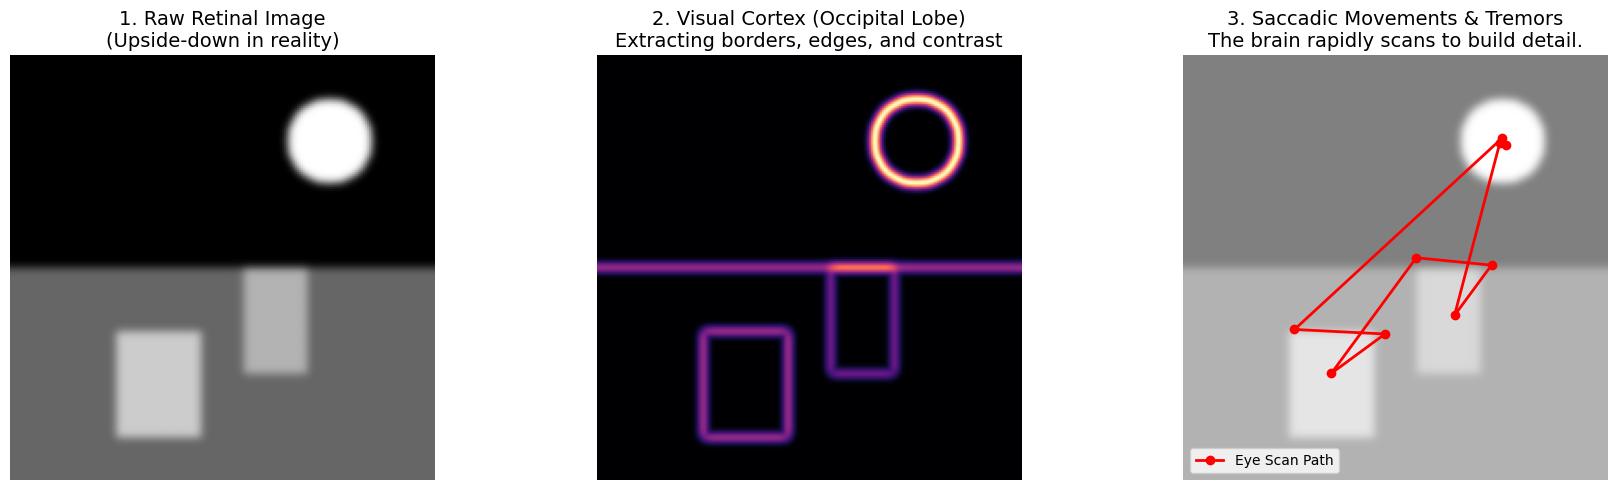

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import sobel, gaussian_filter

def simulate_visual_processing():
    """
    Simulates how the Occipital Lobe extracts edges from a scene, 
    and how Saccadic movements scan a scene for data.
    """
    # 1. Create a synthetic "Retinal Image" (A simple landscape)
    img = np.zeros((200, 200))
    img[100:200, :] = 0.4  # Ground
    img[130:180, 50:90] = 0.8 # Building 1
    img[100:150, 110:140] = 0.7 # Building 2
    
    # Add a "Sun"
    y, x = np.ogrid[0:200, 0:200]
    mask = (x - 150)**2 + (y - 40)**2 <= 20**2
    img[mask] = 1.0
    
    # Add natural blur (imperfections of the human lens)
    retinal_image = gaussian_filter(img, sigma=2)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- Frame 1: Raw Retinal Image ---
    axes[0].imshow(retinal_image, cmap='gray')
    axes[0].set_title("1. Raw Retinal Image\n(Upside-down in reality)", fontsize=14)
    axes[0].axis('off')

    # --- Frame 2: Occipital Lobe (Edge Detection) ---
    # The brain uses lateral inhibition to find edges. We simulate this with a Sobel filter.
    dx = sobel(retinal_image, axis=0) # Find horizontal edges
    dy = sobel(retinal_image, axis=1) # Find vertical edges
    visual_cortex_image = np.hypot(dx, dy) # Combine them
    
    axes[1].imshow(visual_cortex_image, cmap='magma')
    axes[1].set_title("2. Visual Cortex (Occipital Lobe)\nExtracting borders, edges, and contrast", fontsize=14)
    axes[1].axis('off')

    # --- Frame 3: Saccadic Movements ---
    axes[2].imshow(retinal_image, cmap='gray', alpha=0.5)
    
    # Simulate the eye jumping rapidly between points of high interest (edges)
    np.random.seed(42)
    saccade_x = [150, 150, 50, 90, 70, 110, 140, 125, 150]
    saccade_y = [40,  40,  130, 130, 155, 100, 100, 125, 40]
    
    # Add some random micro-tremors (jitter) to the path
    jitter_x = saccade_x + np.random.normal(0, 3, len(saccade_x))
    jitter_y = saccade_y + np.random.normal(0, 3, len(saccade_y))

    axes[2].plot(jitter_x, jitter_y, 'r-o', linewidth=2, markersize=6, label="Eye Scan Path")
    axes[2].set_title("3. Saccadic Movements & Tremors\nThe brain rapidly scans to build detail.", fontsize=14)
    axes[2].axis('off')
    axes[2].legend(loc="lower left")

    plt.tight_layout()
    plt.show()

# Run the simulation!
simulate_visual_processing()